<a href="https://colab.research.google.com/github/anjil2/Machine-learning/blob/main/finalchurn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
df=pd.read_csv('customerchurn.csv')

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.columns=df.columns.str.lower()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   seniorcitizen     7043 non-null   int64  
 3   partner           7043 non-null   object 
 4   dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   phoneservice      7043 non-null   object 
 7   multiplelines     7043 non-null   object 
 8   internetservice   7043 non-null   object 
 9   onlinesecurity    7043 non-null   object 
 10  onlinebackup      7043 non-null   object 
 11  deviceprotection  7043 non-null   object 
 12  techsupport       7043 non-null   object 
 13  streamingtv       7043 non-null   object 
 14  streamingmovies   7043 non-null   object 
 15  contract          7043 non-null   object 
 16  paperlessbilling  7043 non-null   object 


In [ ]:
df.describe()

,seniorcitizen,tenure,monthlycharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.isna().sum()

,0
customerid,0
gender,0
seniorcitizen,0
partner,0
dependents,0
tenure,0
phoneservice,0
multiplelines,0
internetservice,0
onlinesecurity,0


In [ ]:
df.duplicated().sum()


np.int64(0)

In [ ]:
df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   seniorcitizen     7043 non-null   int64  
 3   partner           7043 non-null   object 
 4   dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   phoneservice      7043 non-null   object 
 7   multiplelines     7043 non-null   object 
 8   internetservice   7043 non-null   object 
 9   onlinesecurity    7043 non-null   object 
 10  onlinebackup      7043 non-null   object 
 11  deviceprotection  7043 non-null   object 
 12  techsupport       7043 non-null   object 
 13  streamingtv       7043 non-null   object 
 14  streamingmovies   7043 non-null   object 
 15  contract          7043 non-null   object 
 16  paperlessbilling  7043 non-null   object 


In [ ]:
cat_col=['gender','partner','dependents','phoneservice','multiplelines','internetservice','onlinesecurity','onlinebackup','deviceprotection','techsupport','streamingtv','streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'churn']



In [ ]:
for col in cat_col:
    print(f"\n--- {col} ---")
    print(df[col].unique())
    # print(f"Unique count: {df[col].nunique()}")


--- gender ---
['Female' 'Male']

--- partner ---
['Yes' 'No']

--- dependents ---
['No' 'Yes']

--- phoneservice ---
['No' 'Yes']

--- multiplelines ---
['No phone service' 'No' 'Yes']

--- internetservice ---
['DSL' 'Fiber optic' 'No']

--- onlinesecurity ---
['No' 'Yes' 'No internet service']

--- onlinebackup ---
['Yes' 'No' 'No internet service']

--- deviceprotection ---
['No' 'Yes' 'No internet service']

--- techsupport ---
['No' 'Yes' 'No internet service']

--- streamingtv ---
['No' 'Yes' 'No internet service']

--- streamingmovies ---
['No' 'Yes' 'No internet service']

--- contract ---
['Month-to-month' 'One year' 'Two year']

--- paperlessbilling ---
['Yes' 'No']

--- paymentmethod ---
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

--- churn ---
['No' 'Yes']


In [ ]:
df['totalcharges']=pd.to_numeric(df['totalcharges'],errors='coerce')

In [ ]:
df['totalcharges'].dtypes


dtype('float64')

In [ ]:
df[df['totalcharges'].isnull()]

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [ ]:
df.dropna(subset=['totalcharges'],inplace=True)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   seniorcitizen     7032 non-null   int64  
 3   partner           7032 non-null   object 
 4   dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   phoneservice      7032 non-null   object 
 7   multiplelines     7032 non-null   object 
 8   internetservice   7032 non-null   object 
 9   onlinesecurity    7032 non-null   object 
 10  onlinebackup      7032 non-null   object 
 11  deviceprotection  7032 non-null   object 
 12  techsupport       7032 non-null   object 
 13  streamingtv       7032 non-null   object 
 14  streamingmovies   7032 non-null   object 
 15  contract          7032 non-null   object 
 16  paperlessbilling  7032 non-null   object 
 17  

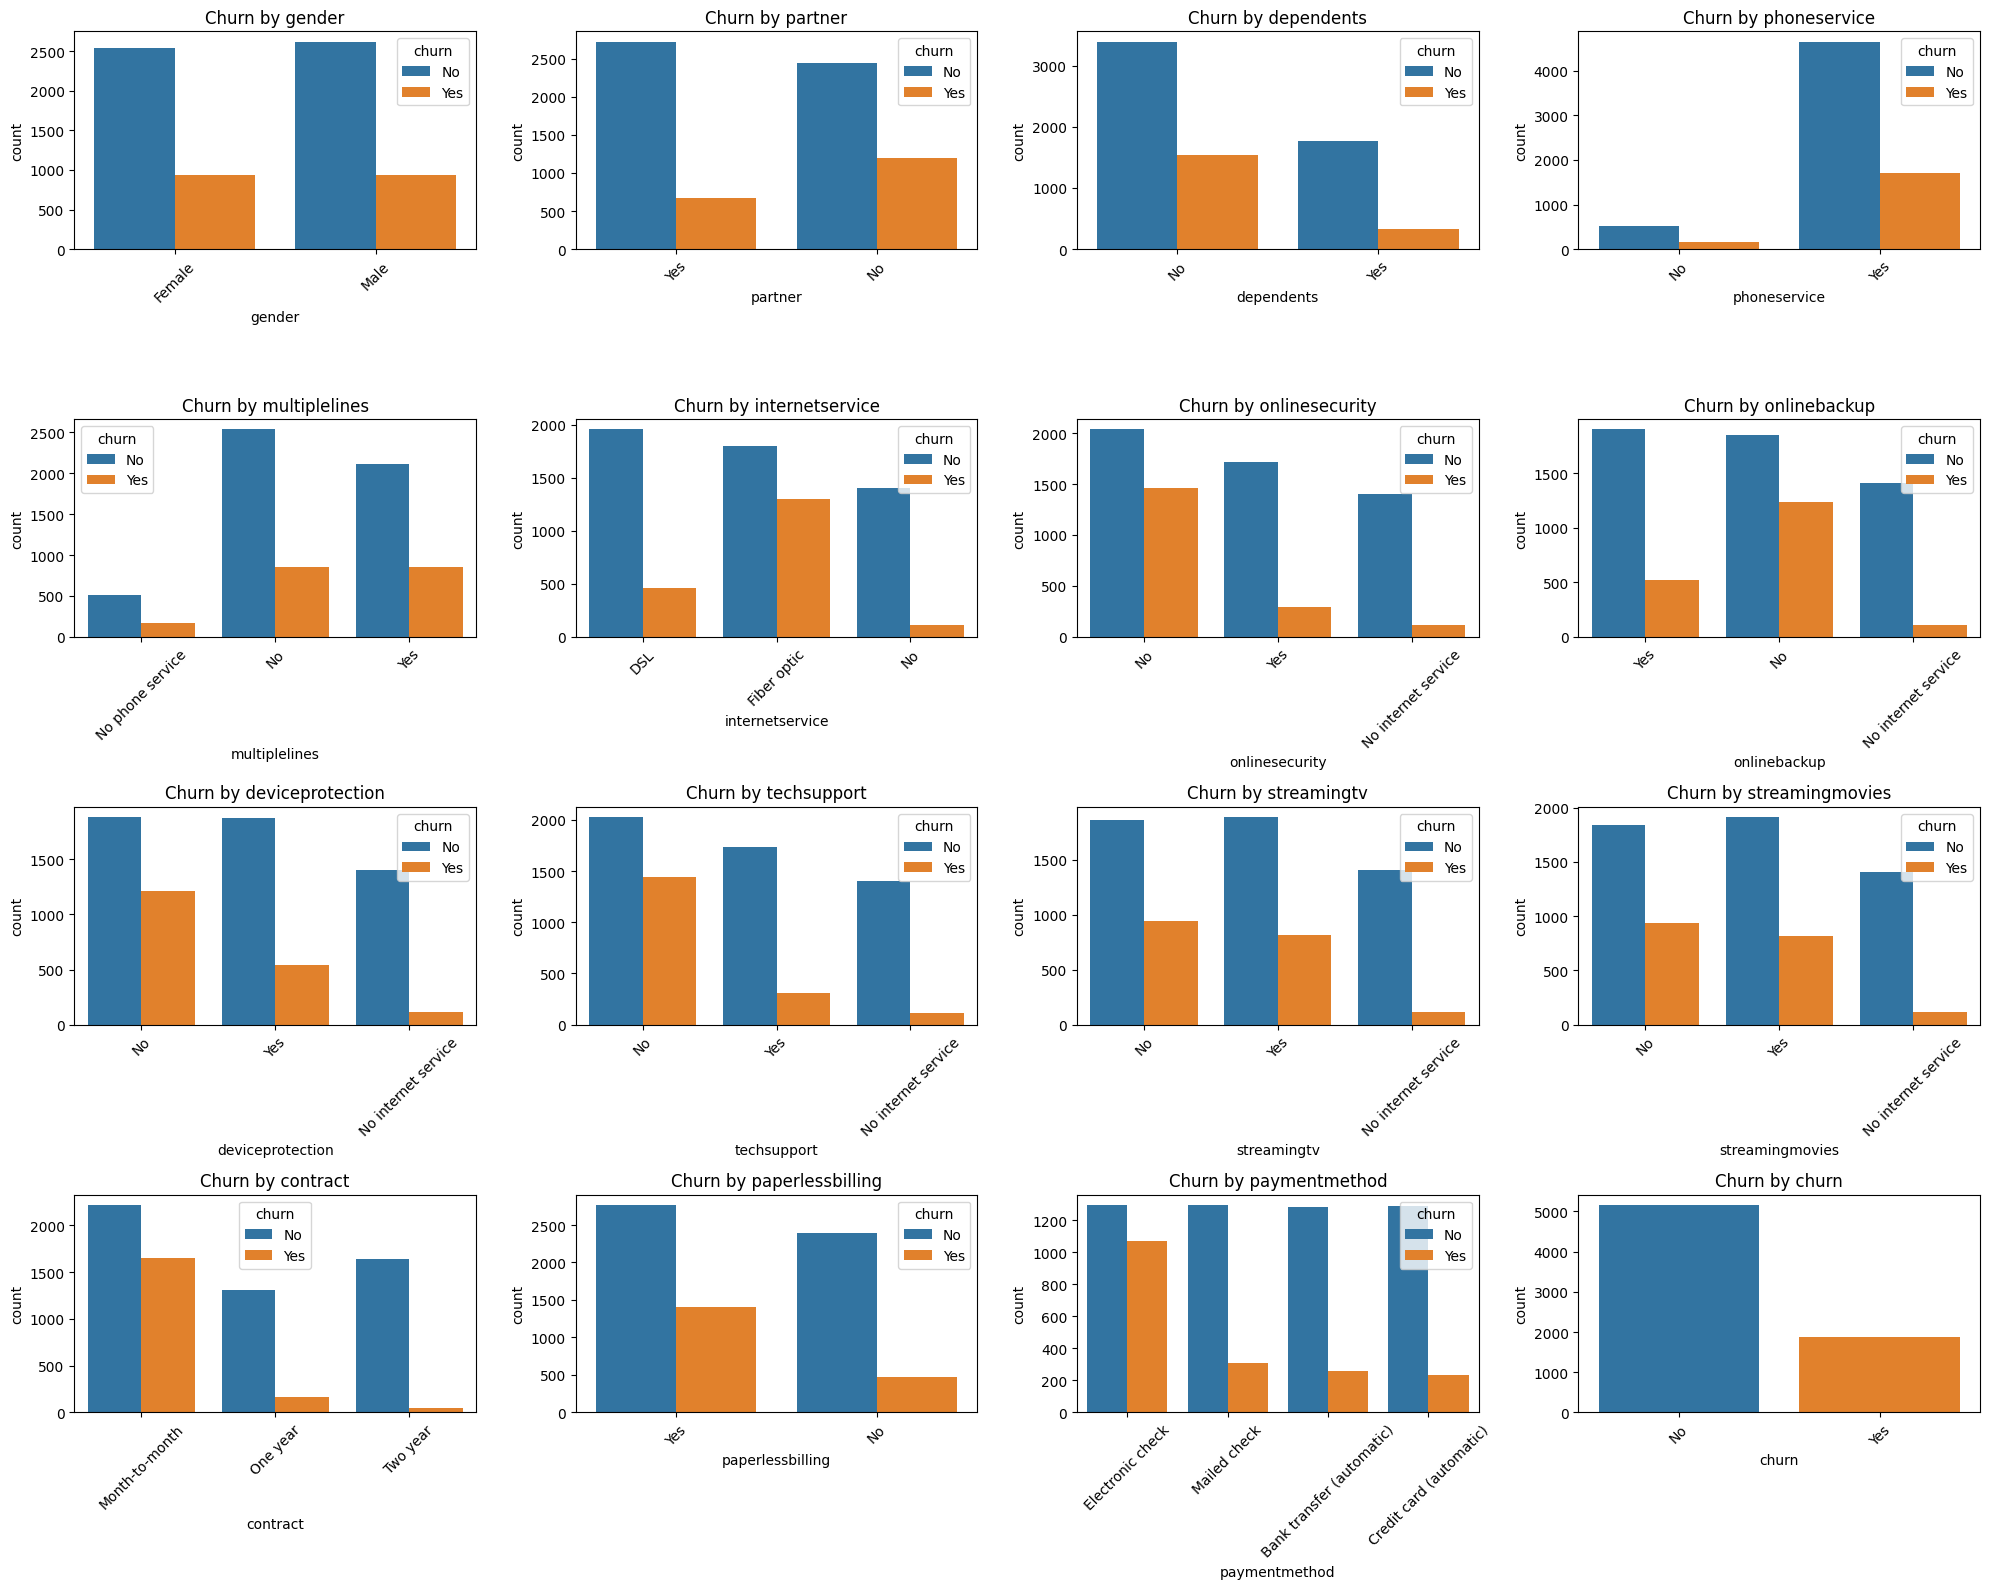

In [ ]:
fig,axes=plt.subplots(4,4,figsize=(20,16)) # Changed to 4x4 to fit all 16 columns
axes=axes.flatten()
for i,col in enumerate(cat_col):
  sns.countplot(data=df,x=col,hue='churn',ax=axes[i])
  axes[i].set_title(f'Churn by {col}')
  axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   seniorcitizen     7032 non-null   int64  
 3   partner           7032 non-null   object 
 4   dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   phoneservice      7032 non-null   object 
 7   multiplelines     7032 non-null   object 
 8   internetservice   7032 non-null   object 
 9   onlinesecurity    7032 non-null   object 
 10  onlinebackup      7032 non-null   object 
 11  deviceprotection  7032 non-null   object 
 12  techsupport       7032 non-null   object 
 13  streamingtv       7032 non-null   object 
 14  streamingmovies   7032 non-null   object 
 15  contract          7032 non-null   object 
 16  paperlessbilling  7032 non-null   object 
 17  

In [ ]:
num_col=['seniorcitizen','tenure','monthlycharges','totalcharges']

In [ ]:
df[num_col]

,seniorcitizen,tenure,monthlycharges,totalcharges
0,0,1,29.85,29.85
1,0,34,56.95,1889.50
2,0,2,53.85,108.15
3,0,45,42.30,1840.75
4,0,2,70.70,151.65
...,...,...,...,...
7038,0,24,84.80,1990.50
7039,0,72,103.20,7362.90
7040,0,11,29.60,346.45
7041,1,4,74.40,306.60


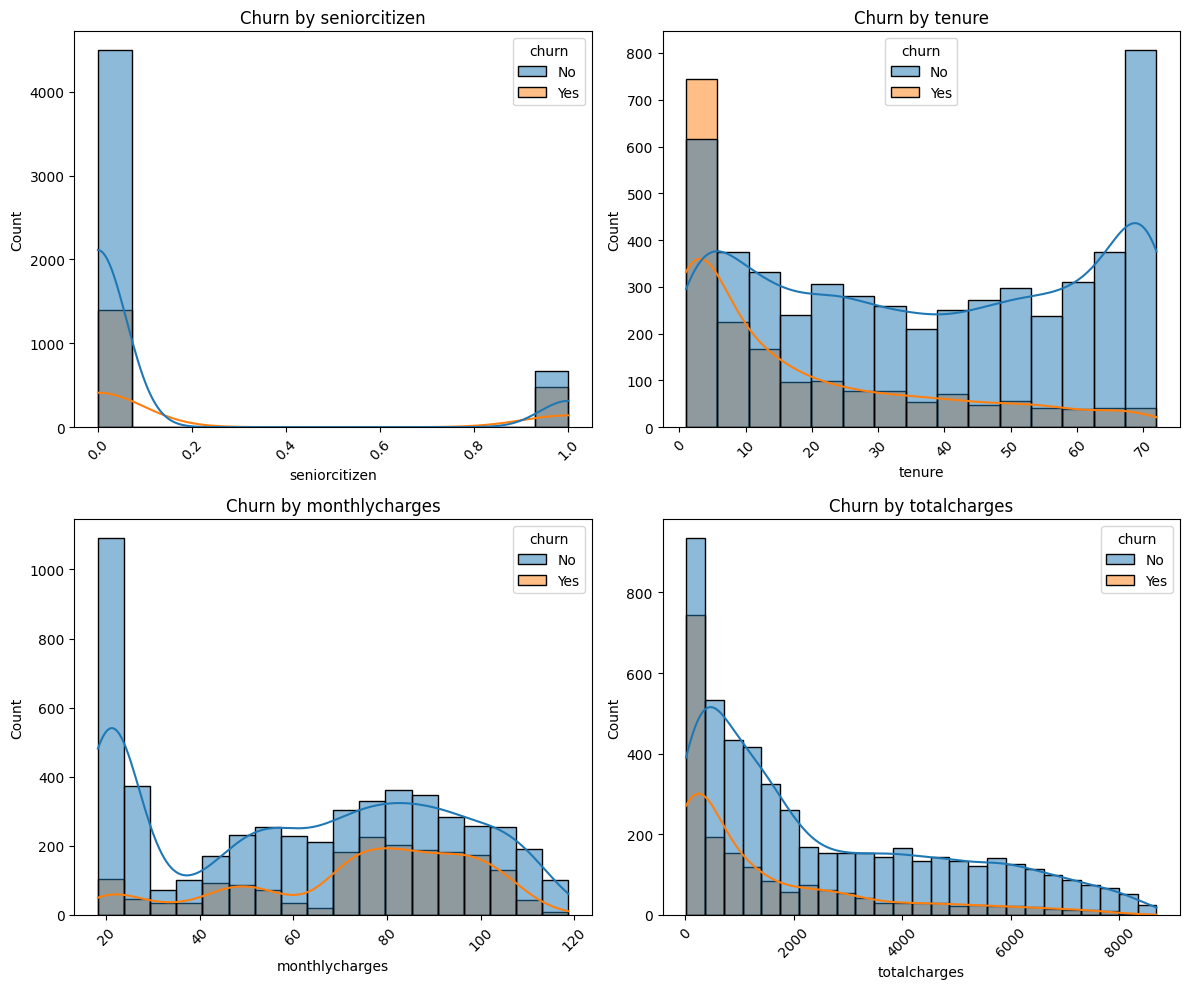

In [ ]:
fig,axes=plt.subplots(2,2,figsize=(12,10))
axes=axes.flatten()
for i,col in enumerate(num_col):
  sns.histplot(data=df,x=col,hue='churn',ax=axes[i],kde=True)
  axes[i].set_title(f'Churn by {col}')
  axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
corr=df[num_col].corr()

In [ ]:
corr

,seniorcitizen,tenure,monthlycharges,totalcharges
seniorcitizen,1.000000,0.015683,0.219874,0.102411
tenure,0.015683,1.000000,0.246862,0.825880
monthlycharges,0.219874,0.246862,1.000000,0.651065
totalcharges,0.102411,0.825880,0.651065,1.000000


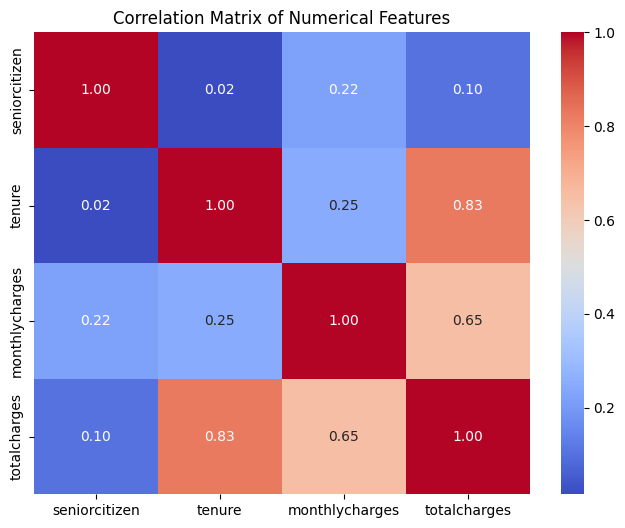

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [ ]:
print(df['churn'].value_counts())


churn
No     5163
Yes    1869
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
df[cat_col]

,gender,partner,dependents,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,churn
0,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,No
1,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,No
2,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,Yes
3,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),No
4,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,No
7039,Female,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),No
7040,Female,Yes,Yes,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
7041,Male,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,Yes


In [ ]:
le=LabelEncoder()
for col in cat_col:
 df[col]=le.fit_transform(df[col])


In [ ]:
df[cat_col]

,gender,partner,dependents,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,churn
0,0,1,0,0,1,0,0,2,0,0,0,0,0,1,2,0
1,1,0,0,1,0,0,2,0,2,0,0,0,1,0,3,0
2,1,0,0,1,0,0,2,2,0,0,0,0,0,1,3,1
3,1,0,0,0,1,0,2,0,2,2,0,0,1,0,0,0
4,0,0,0,1,0,1,0,0,0,0,0,0,0,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,1,1,1,2,0,2,0,2,2,2,2,1,1,3,0
7039,0,1,1,1,2,1,0,2,2,0,2,2,1,1,1,0
7040,0,1,1,0,1,0,2,0,0,0,0,0,0,1,2,0
7041,1,1,0,1,2,1,0,0,0,0,0,0,0,1,3,1


In [ ]:
df['churn'].unique()

array([0, 1])

In [ ]:
df.drop(['customerid'],axis=1,inplace=True)

In [ ]:
df

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1990.50,0
7039,0,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,7362.90,0
7040,0,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2,29.60,346.45,0
7041,1,1,1,0,4,1,2,1,0,0,0,0,0,0,0,1,3,74.40,306.60,1


In [ ]:
df.dtypes

,0
gender,int64
seniorcitizen,int64
partner,int64
dependents,int64
tenure,int64
phoneservice,int64
multiplelines,int64
internetservice,int64
onlinesecurity,int64
onlinebackup,int64


In [ ]:
X=df.drop('churn',axis=1)
y=df['churn']

In [ ]:
y

,churn
0,0
1,0
2,1
3,0
4,1
...,...
7038,0
7039,0
7040,0
7041,1


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [ ]:
# X_train_scaled=scaler.fit_transform(X_train[num_col])
# X_test_scaled=scaler.transform(X_test[num_col])

In [ ]:
# X_train_scaled=pd.DataFrame(X_train_scaled,columns=num_col)

In [ ]:
# X_test_scaled=pd.DataFrame(X_test_scaled,columns=num_col)

In [ ]:
# X_train_scaled

In [ ]:
# X_test_scaled

In [ ]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()

In [ ]:
# model.fit(X_train_scaled,y_train)

In [ ]:

# y_pred=model.predict(X_test_scaled)

In [ ]:
# y_pred

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [ ]:
# accuracy_score(y_test,y_pred)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn_model=KNeighborsClassifier(n_neighbors=5)

In [ ]:
# knn_model.fit(X_train_scaled,y_train)

In [ ]:
# y_knn_pred=knn_model.predict(X_test_scaled)

In [ ]:
# accuracy_score(y_test,y_knn_pred)

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
model_nb=GaussianNB()

In [ ]:
# model_nb.fit(X_train_scaled,y_train)

In [ ]:
# y_pred_nb=model_nb.predict(X_test_scaled)

In [ ]:
# accuracy_score(y_test,y_pred_nb)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
model_tree=DecisionTreeClassifier()

In [ ]:
# model_tree.fit(X_train_scaled,y_train)

In [ ]:
# y_pred_tree=model_tree.predict(X_test_scaled)

In [ ]:
# accuracy_score(y_test,y_pred_tree)

In [ ]:
from sklearn.svm import SVC

In [ ]:
model_svm=SVC()

In [ ]:
# model_svm.fit(X_train_scaled,y_train)

In [ ]:
# y_pred_svm=model_svm.predict(X_test_scaled)

In [ ]:
# accuracy_score(y_test,y_pred_svm)

Cross Validation

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
pipeline_lr= Pipeline([
    ('scaler',StandardScaler()),
    ('classifier',LogisticRegression())
])
pipeline_knn= Pipeline([
    ('scaler',StandardScaler()),
    ('classifier',KNeighborsClassifier())
])
pipeline_nb= Pipeline([
    ('scaler',StandardScaler()),
    ('classifier',GaussianNB())
])
pipeline_tree= Pipeline([
    ('scaler',StandardScaler()),
    ('classifier',DecisionTreeClassifier())
])
pipeline_svm= Pipeline([
    ('scaler',StandardScaler()),
    ('classifier',SVC())
])
from sklearn.ensemble import RandomForestClassifier
pipeline_rf= Pipeline([
    ('scaler',StandardScaler()),
    ('classifier',RandomForestClassifier())
])

In [ ]:
pipelines={
    'LogisticRegression':pipeline_lr,
    'KNeighborsClassifier':pipeline_knn,
    'GaussianNB':pipeline_nb,
    'DecisionTreeClassifier':pipeline_tree,
    'SVC':pipeline_svm,
    'RandomForestClassifier':pipeline_rf
}

In [ ]:
for pipeline in pipelines.values():
  scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')
  print(scores)

[0.80454869 0.80881308 0.78520626 0.80512091 0.8029872 ]
[0.76545842 0.75692964 0.73897582 0.74395448 0.75889047]
[0.75195451 0.7583511  0.73826458 0.76173542 0.75320057]
[0.74769012 0.73276475 0.71834993 0.69843528 0.74822191]
[0.80312722 0.80668088 0.78805121 0.79800853 0.80369844]
[0.79957356 0.79033404 0.77027027 0.79800853 0.79302987]


Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid={
    'classifier__C':[0.01,0.1,1,10],
    'classifier__penalty':['l1','l2'],
    'classifier__solver':['saga'],
    'classifier__max_iter':[100,500,1000],
     'classifier__class_weight': ['balanced', {0:1, 1:2}, {0:1, 1:3}, {0:1, 1:5}]
}

For Lr

In [ ]:
grid=GridSearchCV(
    estimator=pipeline_lr,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
    # n_jobs=2,
    # verbose=1
)

In [ ]:
grid

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('classifier', LogisticRegression())]),
             param_grid={'classifier__C': [0.01, 0.1, 1, 10],
                         'classifier__class_weight': ['balanced', {0: 1, 1: 2},
                                                      {0: 1, 1: 3},
                                                      {0: 1, 1: 5}],
                         'classifier__max_iter': [100, 500, 1000],
                         'classifier__penalty': ['l1', 'l2'],
                         'classifier__solver': ['saga']},
             scoring='accuracy')

In [ ]:
grid.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('classifier', LogisticRegression())]),
             param_grid={'classifier__C': [0.01, 0.1, 1, 10],
                         'classifier__class_weight': ['balanced', {0: 1, 1: 2},
                                                      {0: 1, 1: 3},
                                                      {0: 1, 1: 5}],
                         'classifier__max_iter': [100, 500, 1000],
                         'classifier__penalty': ['l1', 'l2'],
                         'classifier__solver': ['saga']},
             scoring='accuracy')

In [ ]:
grid.best_params_

{'classifier__C': 0.1,
 'classifier__class_weight': {0: 1, 1: 2},
 'classifier__max_iter': 100,
 'classifier__penalty': 'l1',
 'classifier__solver': 'saga'}

In [ ]:
grid.best_score_

np.float64(0.7738666666666667)

In [ ]:
grid.score(X_test,y_test)

0.7590618336886994

In [ ]:
y_pred_tune=grid.predict(X_test)

In [ ]:
y_pred_tune

array([0, 0, 1, ..., 0, 0, 0])

In [ ]:
accuracy_score(y_test,y_pred_tune)

0.7590618336886994

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score, GridSearchCV
import numpy as np

# After hyperparameter tuning (e.g., GridSearchCV)
# Assuming you have your best model and test data

# Get predictions
y_pred = grid.best_estimator_.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')  # For multi-class
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Accuracy: 0.7591
Precision: 0.7917
Recall: 0.7591
F1-Score: 0.7689
